In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.style as style
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy import stats
from scipy.stats import spearmanr
from scipy.stats import mannwhitneyu

# 1) Folder setup (data in / outputs out)
DATA_DIR = Path("data")
OUT_DIR = Path("outputs")

DATA_DIR.mkdir(exist_ok=True)
OUT_DIR.mkdir(exist_ok=True)


# 2) Helper functions
def clean_zip(value):
    """
    Convert a ZIP value into a clean 5-digit ZIP string.
    Returns np.nan if the value is missing or invalid.

    Handles:
    - floats like 90012.0
    - ZIP+4 like "90012-1234"
    - short ZIPs like "123" -> "00123"
    """
    if pd.isna(value):
        return np.nan

    s = str(value).strip()

    # Remove trailing ".0" if it came in as a float (common in CSVs)
    if s.endswith(".0"):
        s = s[:-2]

    # If ZIP+4 format, keep only the first 5 digits
    if "-" in s:
        s = s.split("-", 1)[0]

    # Keep only digits (in case of weird formatting like "90012 ")
    if not s.isdigit():
        return np.nan

    # Pad to 5 digits (e.g., "123" -> "00123")
    return s.zfill(5)


def find_first_col(df, candidates):
    """
    Find the first column in df that matches one of the candidate names
    (case-insensitive). Returns the actual column name or None.
    """
    # Map lowercase column name -> actual column name
    lower_to_actual = {col.lower(): col for col in df.columns}

    for name in candidates:
        key = name.lower()
        if key in lower_to_actual:
            return lower_to_actual[key]

    return None


def coerce_date(df, date_col):
    """
    Convert a date column into real datetime values.
    Invalid dates become NaT (missing).
    """
    df = df.copy()
    df[date_col] = pd.to_datetime(df[date_col], errors="coerce")
    return df


def snapshot_asof(df, zip_col="zip", date_col="date", asof="2023-05-31"):
    """
    For each ZIP, keep the most recent row where date <= asof.
    Useful when you have daily/weekly time series data and want a single snapshot.

    Steps:
    1) Drop rows missing ZIP or date
    2) Keep only rows on/before the asof date
    3) For each ZIP, take the latest (max) date row
    """
    asof = pd.Timestamp(asof)

    # Work on a clean copy
    df = df.copy()

    # Drop rows missing ZIP/date
    df = df.dropna(subset=[zip_col, date_col])

    # Keep only rows up to the asof date
    df = df[df[date_col] <= asof]

    # Sort so the latest date per ZIP is at the bottom
    df = df.sort_values([zip_col, date_col])

    # Take the last row per ZIP (latest date)
    latest_per_zip = df.groupby(zip_col, as_index=False).tail(1)

    return latest_per_zip.reset_index(drop=True)

In [2]:
DATADESK_URL = "https://raw.githubusercontent.com/datadesk/california-coronavirus-data/master/cdph-vaccination-zipcode-totals.csv"
datadesk_raw = pd.read_csv(DATADESK_URL)

datadesk_raw.shape, datadesk_raw.head(3)

((143988, 11),
          date     id       county  fips  population  partially_vaccinated  \
 0  2021-08-17  90005  Los Angeles    37     39479.0                  3436   
 1  2021-08-17  90007  Los Angeles    37     41716.0                  3659   
 2  2021-08-17  90019  Los Angeles    37     66245.0                  5182   
 
    at_least_one_dose  fully_vaccinated  partially_vaccinated_percent  \
 0              26255             22819                          0.09   
 1              30782             27123                          0.09   
 2              42474             37292                          0.08   
 
    at_least_one_dose_percent  fully_vaccinated_percent  
 0                       0.67                      0.58  
 1                       0.74                      0.65  
 2                       0.64                      0.56  )

In [3]:
datadesk = datadesk_raw.copy()

# ZIP code (id column)
datadesk["zip"] = datadesk["id"].astype(str).str.zfill(5)

# Convert date column
datadesk["date"] = pd.to_datetime(datadesk["date"])

datadesk.head()

,date,id,county,fips,population,partially_vaccinated,at_least_one_dose,fully_vaccinated,partially_vaccinated_percent,at_least_one_dose_percent,fully_vaccinated_percent,zip
0,2021-08-17,90005,Los Angeles,37,39479.0,3436,26255,22819,0.09,0.67,0.58,90005
1,2021-08-17,90007,Los Angeles,37,41716.0,3659,30782,27123,0.09,0.74,0.65,90007
2,2021-08-17,90019,Los Angeles,37,66245.0,5182,42474,37292,0.08,0.64,0.56,90019
3,2021-08-17,90024,Los Angeles,37,50288.0,2386,25869,23483,0.05,0.51,0.47,90024
4,2021-08-17,90025,Los Angeles,37,47967.0,2774,33549,30775,0.06,0.70,0.64,90025


In [4]:
datadesk_la = datadesk[datadesk["county"] == "Los Angeles"].copy()

print("Rows:", len(datadesk_la))
print("Unique ZIPs:", datadesk_la["zip"].nunique())

Rows: 25618
Unique ZIPs: 276


In [5]:
start = pd.Timestamp("2021-08-01")
end = pd.Timestamp("2023-05-31")

datadesk_la = datadesk_la[
    (datadesk_la["date"] >= start) &
    (datadesk_la["date"] <= end)
].copy()

datadesk_la["date"].min(), datadesk_la["date"].max()

(Timestamp('2021-08-17 00:00:00'), Timestamp('2023-05-30 00:00:00'))

In [6]:
datadesk_la = datadesk_la.sort_values(["zip", "date"])

datadesk_snapshot = (
    datadesk_la
    .groupby("zip", as_index=False)
    .tail(1)
)
datadesk_snapshot = datadesk_snapshot.copy()
#you can increase or decrease the number from 20 if you wanna view more data
datadesk_snapshot.head(50)

,date,id,county,fips,population,partially_vaccinated,at_least_one_dose,fully_vaccinated,partially_vaccinated_percent,at_least_one_dose_percent,fully_vaccinated_percent,zip
142387,2023-05-30,90001,Los Angeles,37,58975.0,13713,58066,44353,0.23,0.98,0.75,90001
142388,2023-05-30,90002,Los Angeles,37,53111.0,5338,40763,35425,0.10,0.77,0.67,90002
142389,2023-05-30,90003,Los Angeles,37,72741.0,8531,57564,49033,0.12,0.79,0.67,90003
142390,2023-05-30,90004,Los Angeles,37,61586.0,5969,53241,47272,0.10,0.86,0.77,90004
142391,2023-05-30,90005,Los Angeles,37,39479.0,4436,33905,29469,0.11,0.86,0.75,90005
142392,2023-05-30,90006,Los Angeles,37,61698.0,6905,50835,43930,0.11,0.82,0.71,90006
142393,2023-05-30,90007,Los Angeles,37,41716.0,6220,41143,34923,0.15,0.99,0.84,90007
142394,2023-05-30,90008,Los Angeles,37,31739.0,2531,24395,21864,0.08,0.77,0.69,90008
142395,2023-05-30,90010,Los Angeles,37,3702.0,884,5136,4252,0.24,1.39,1.15,90010
142396,2023-05-30,90011,Los Angeles,37,109414.0,15483,85612,70129,0.14,0.78,0.64,90011


In [7]:
datadesk_snapshot["vax_rate"] = pd.to_numeric(
    datadesk_snapshot["fully_vaccinated_percent"],
    errors="coerce"
)

# Remove infinite values
datadesk_snapshot["vax_rate"].replace([np.inf, -np.inf], np.nan, inplace=True)

datadesk_snapshot["vax_rate"].describe()

/tmp/ipykernel_1043/2241526977.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  datadesk_snapshot["vax_rate"].replace([np.inf, -np.inf], np.nan, inplace=True)


count    275.000000
mean       0.759891
std        0.114077
min        0.270000
25%        0.705000
50%        0.750000
75%        0.810000
max        1.660000
Name: vax_rate, dtype: float64

In [8]:
datadesk_snapshot["id"].unique()

array([90001, 90002, 90003, 90004, 90005, 90006, 90007, 90008, 90010,
       90011, 90012, 90013, 90014, 90015, 90016, 90017, 90018, 90019,
       90020, 90021, 90022, 90023, 90024, 90025, 90026, 90027, 90028,
       90029, 90031, 90032, 90033, 90034, 90035, 90036, 90037, 90038,
       90039, 90040, 90041, 90042, 90043, 90044, 90045, 90046, 90047,
       90048, 90049, 90056, 90057, 90058, 90059, 90061, 90062, 90063,
       90064, 90065, 90066, 90067, 90068, 90069, 90071, 90077, 90094,
       90201, 90210, 90211, 90212, 90220, 90221, 90222, 90230, 90232,
       90240, 90241, 90242, 90245, 90247, 90248, 90249, 90250, 90254,
       90255, 90260, 90262, 90263, 90265, 90266, 90270, 90272, 90274,
       90275, 90277, 90278, 90280, 90290, 90291, 90292, 90293, 90301,
       90302, 90303, 90304, 90305, 90401, 90402, 90403, 90404, 90405,
       90501, 90502, 90503, 90504, 90505, 90601, 90602, 90603, 90604,
       90605, 90606, 90638, 90640, 90650, 90660, 90670, 90701, 90703,
       90704, 90706,

In [9]:
datadesk_snapshot

,date,id,county,fips,population,partially_vaccinated,at_least_one_dose,fully_vaccinated,partially_vaccinated_percent,at_least_one_dose_percent,fully_vaccinated_percent,zip,vax_rate
142387,2023-05-30,90001,Los Angeles,37,58975.0,13713,58066,44353,0.23,0.98,0.75,90001,0.75
142388,2023-05-30,90002,Los Angeles,37,53111.0,5338,40763,35425,0.10,0.77,0.67,90002,0.67
142389,2023-05-30,90003,Los Angeles,37,72741.0,8531,57564,49033,0.12,0.79,0.67,90003,0.67
142390,2023-05-30,90004,Los Angeles,37,61586.0,5969,53241,47272,0.10,0.86,0.77,90004,0.77
142391,2023-05-30,90005,Los Angeles,37,39479.0,4436,33905,29469,0.11,0.86,0.75,90005,0.75
...,...,...,...,...,...,...,...,...,...,...,...,...,...
143147,2023-05-30,93550,Los Angeles,37,77006.0,5170,54215,49045,0.07,0.70,0.64,93550,0.64
143148,2023-05-30,93551,Los Angeles,37,51085.0,2921,39150,36229,0.06,0.77,0.71,93551,0.71
143149,2023-05-30,93552,Los Angeles,37,40266.0,2503,30546,28043,0.06,0.76,0.70,93552,0.70
143150,2023-05-30,93553,Los Angeles,37,1781.0,100,1061,961,0.06,0.60,0.54,93553,0.54


In [10]:
datadesk_snapshot.describe()

,date,id,fips,population,partially_vaccinated,at_least_one_dose,fully_vaccinated,partially_vaccinated_percent,at_least_one_dose_percent,fully_vaccinated_percent,vax_rate
count,276,276.000000,276.0,276.000000,276.000000,276.000000,276.000000,276.00,276.000,276.0000,275.000000
mean,2023-05-30 00:00:00,90896.380435,37.0,36529.746377,3028.268116,30139.358696,27111.090580,inf,inf,inf,0.759891
min,2023-05-30 00:00:00,90001.000000,37.0,0.000000,15.000000,150.000000,135.000000,0.03,0.390,0.2700,0.270000
25%,2023-05-30 00:00:00,90221.750000,37.0,22752.000000,1665.500000,20121.750000,17849.500000,0.07,0.780,0.7075,0.705000
50%,2023-05-30 00:00:00,90744.500000,37.0,33058.000000,2592.500000,27440.000000,25164.500000,0.08,0.825,0.7500,0.750000
75%,2023-05-30 00:00:00,91364.750000,37.0,47213.750000,3832.250000,39183.000000,35112.750000,0.09,0.900,0.8100,0.810000
max,2023-05-30 00:00:00,93591.000000,37.0,109414.000000,15483.000000,85612.000000,76941.000000,inf,inf,inf,1.660000
std,NaN,829.766620,0.0,21157.941345,2104.965798,16567.529058,14763.626729,NaN,NaN,NaN,0.114077


In [11]:
#finding infinite values
datadesk_snapshot['fully_vaccinated_percent'].max()

inf

In [12]:
#identify how many rows
np.isinf(datadesk_snapshot['fully_vaccinated_percent']).sum()

1

In [13]:
#eliminated inifite value row
datadesk_snapshot['fully_vaccinated_percent'] = datadesk_snapshot['fully_vaccinated_percent'].replace([np.inf, -np.inf], np.nan)

In [14]:
datadesk_snapshot['fully_vaccinated_percent'].max()

1.66

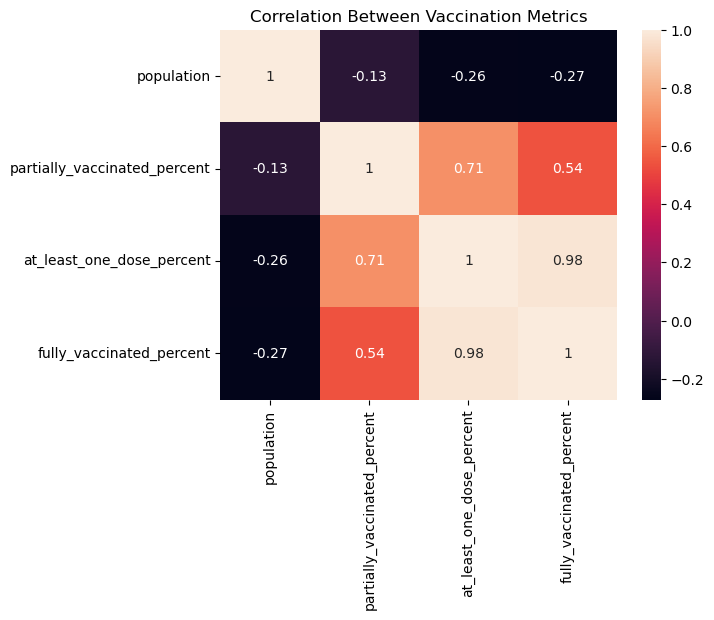

In [15]:
corr = datadesk_snapshot[[
    'population',
    'partially_vaccinated_percent',
    'at_least_one_dose_percent',
    'fully_vaccinated_percent'
]].corr()

sns.heatmap(corr, annot=True)

plt.title("Correlation Between Vaccination Metrics")
plt.show()

In [16]:
#Setting fully vaccinated max as 100%
datadesk_snapshot['fully_vaccinated_percent'] = datadesk_snapshot['fully_vaccinated_percent'].clip(upper=1)

In [17]:
#converting fully vaccinated to percentage
datadesk_snapshot['fully_vaccinated_percent'] = datadesk_snapshot['fully_vaccinated_percent'] * 100

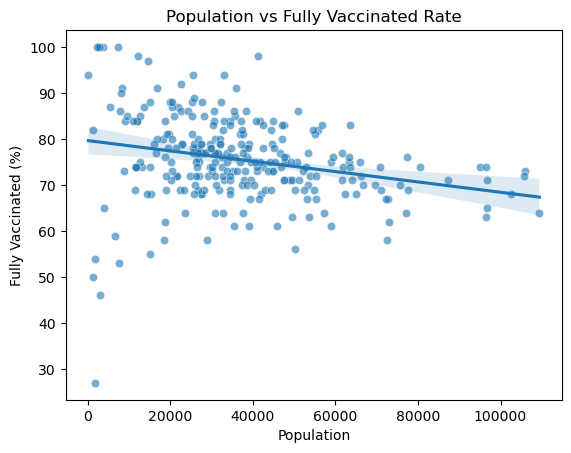

In [18]:
sns.scatterplot(
    data=datadesk_snapshot,
    x='population',
    y='fully_vaccinated_percent',
    alpha=0.6
)

sns.regplot(
    data=datadesk_snapshot,
    x='population',
    y='fully_vaccinated_percent',
    scatter=False
)

plt.title("Population vs Fully Vaccinated Rate")
plt.xlabel("Population")
plt.ylabel("Fully Vaccinated (%)")
plt.show()



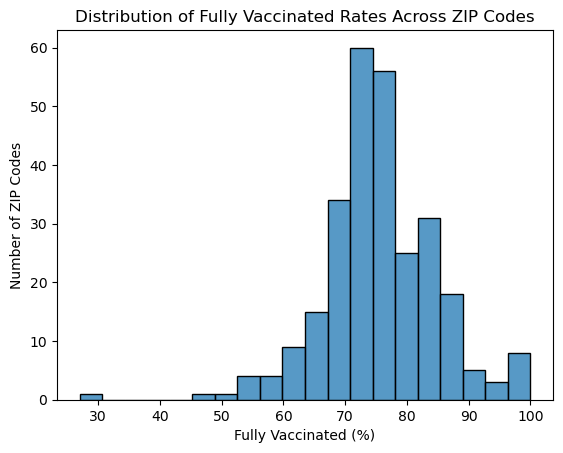

In [19]:
sns.histplot(
    data=datadesk_snapshot,
    x='fully_vaccinated_percent',
    bins=20
)

plt.title("Distribution of Fully Vaccinated Rates Across ZIP Codes")
plt.xlabel("Fully Vaccinated (%)")
plt.ylabel("Number of ZIP Codes")
plt.show()

In [20]:
#maxxing at least one dose at 100
datadesk_snapshot['at_least_one_dose_percent'] = datadesk_snapshot['at_least_one_dose_percent'].clip(upper=1)

In [21]:
#converting at least one dose to percentage
datadesk_snapshot['at_least_one_dose_percent'] = datadesk_snapshot['at_least_one_dose_percent'] * 100

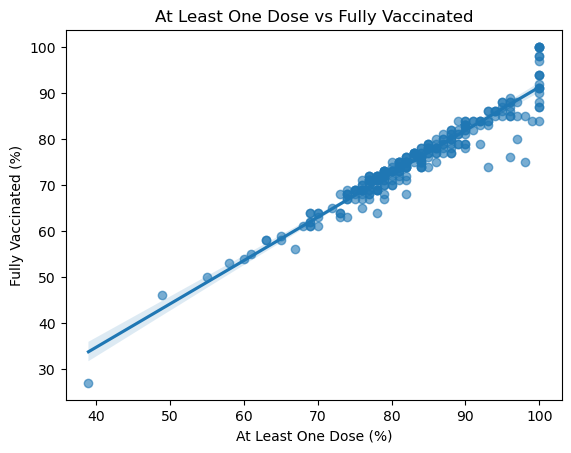

In [22]:
sns.regplot(
    data=datadesk_snapshot,
    x='at_least_one_dose_percent',
    y='fully_vaccinated_percent',
    scatter_kws={'alpha':0.6}
)

plt.title("At Least One Dose vs Fully Vaccinated")
plt.xlabel("At Least One Dose (%)")
plt.ylabel("Fully Vaccinated (%)")
plt.show()

In [23]:
income_2023 = pd.read_csv("income_data/LA County Median Income 2023.csv")

In [24]:
income_2023

,Zip Code,Estimated Median Income
0,90001,"$60,751"
1,90002,"$56,158"
2,90003,"$54,781"
3,90004,"$62,655"
4,90005,"$52,755"
...,...,...
278,93551,"$110,850"
279,93552,"$84,894"
280,93553,"$73,029"
281,93563,"No 2023 estimate ($210,600 in 2021)†"


In [25]:
income_2021 = pd.read_csv("income_data/LA County Median Income Data - 2021.csv")

In [26]:
income_2021

,Zip Code,Estimated Median Income
0,90001,"$52,806"
1,90002,"$46,159"
2,90003,"$47,733"
3,90004,"$54,947"
4,90005,"$44,913"
...,...,...
277,93551,"$98,181"
278,93552,"$73,074"
279,93553,"$59,805"
280,93563,"$210,600"


In [27]:
income_2023 = income_2023.rename(columns={
    'Zip Code': 'zip',
    'Estimated Median Income': 'median_income_2023'
})
income_2023['zip'] = income_2023['zip'].astype(str)

In [28]:
income_2021 = income_2021.rename(columns={
    'Zip Code': 'zip',
    'Estimated Median Income': 'median_income_2021'
})
income_2021['zip'] = income_2021['zip'].astype(str)

In [29]:
datadesk_snapshot['zip'] = datadesk_snapshot['zip'].astype(str)

In [30]:
snapshot_with_income = datadesk_snapshot.merge(
    income_2023, how='left', on='zip'
).merge(
    income_2021, how='left', on='zip'
)

In [31]:
snapshot_with_income['date'] = pd.to_datetime(snapshot_with_income['date'])

In [32]:
snapshot_with_income['year'] = snapshot_with_income['date'].dt.year

In [33]:
snapshot_with_income['median_income'] = np.where(
    snapshot_with_income['year'] == 2021,
    snapshot_with_income['median_income_2021'],
    snapshot_with_income['median_income_2023']
)

In [34]:
snapshot_with_income

,date,id,county,fips,population,partially_vaccinated,at_least_one_dose,fully_vaccinated,partially_vaccinated_percent,at_least_one_dose_percent,fully_vaccinated_percent,zip,vax_rate,median_income_2023,median_income_2021,year,median_income
0,2023-05-30,90001,Los Angeles,37,58975.0,13713,58066,44353,0.23,98.0,75.0,90001,0.75,"$60,751","$52,806",2023,"$60,751"
1,2023-05-30,90002,Los Angeles,37,53111.0,5338,40763,35425,0.10,77.0,67.0,90002,0.67,"$56,158","$46,159",2023,"$56,158"
2,2023-05-30,90003,Los Angeles,37,72741.0,8531,57564,49033,0.12,79.0,67.0,90003,0.67,"$54,781","$47,733",2023,"$54,781"
3,2023-05-30,90004,Los Angeles,37,61586.0,5969,53241,47272,0.10,86.0,77.0,90004,0.77,"$62,655","$54,947",2023,"$62,655"
4,2023-05-30,90005,Los Angeles,37,39479.0,4436,33905,29469,0.11,86.0,75.0,90005,0.75,"$52,755","$44,913",2023,"$52,755"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
271,2023-05-30,93550,Los Angeles,37,77006.0,5170,54215,49045,0.07,70.0,64.0,93550,0.64,"$63,811","$54,693",2023,"$63,811"
272,2023-05-30,93551,Los Angeles,37,51085.0,2921,39150,36229,0.06,77.0,71.0,93551,0.71,"$110,850","$98,181",2023,"$110,850"
273,2023-05-30,93552,Los Angeles,37,40266.0,2503,30546,28043,0.06,76.0,70.0,93552,0.70,"$84,894","$73,074",2023,"$84,894"
274,2023-05-30,93553,Los Angeles,37,1781.0,100,1061,961,0.06,60.0,54.0,93553,0.54,"$73,029","$59,805",2023,"$73,029"


In [35]:
snapshot_with_income.dtypes

date                            datetime64[ns]
id                                       int64
county                                  object
fips                                     int64
population                             float64
partially_vaccinated                     int64
at_least_one_dose                        int64
fully_vaccinated                         int64
partially_vaccinated_percent           float64
at_least_one_dose_percent              float64
fully_vaccinated_percent               float64
zip                                     object
vax_rate                               float64
median_income_2023                      object
median_income_2021                      object
year                                     int32
median_income                           object
dtype: object

In [36]:
# Convert all median income columns to numeric
for col in ['median_income', 'median_income_2021', 'median_income_2023']:
    snapshot_with_income[col] = (
        snapshot_with_income[col]
        .replace('[\$,]', '', regex=True)  # remove $ and commas
    )
    snapshot_with_income[col] = pd.to_numeric(
        snapshot_with_income[col],
        errors='coerce'  # invalid entries become NaN
    )

In [37]:
snapshot_with_income['median_income'].dtype

dtype('float64')

In [38]:
#Checking for any weird values
snapshot_with_income['median_income'].describe()

count       273.000000
mean      96789.750916
std       34072.944719
min       32250.000000
25%       72152.000000
50%       92815.000000
75%      112888.000000
max      222273.000000
Name: median_income, dtype: float64

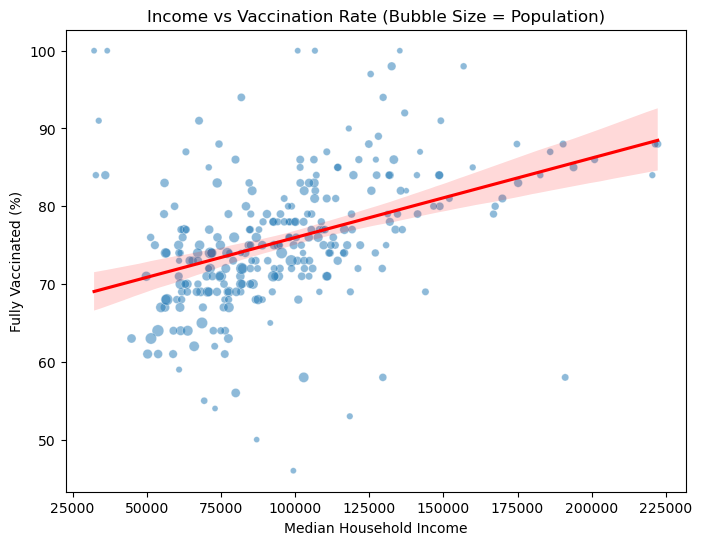

In [39]:
plt.figure(figsize=(8,6))

# Bubble scatter
sns.scatterplot(
    data=snapshot_with_income,
    x='median_income',
    y='fully_vaccinated_percent',
    size='population',
    alpha=0.5,
    legend=False
)

# Regression line
sns.regplot(
    data=snapshot_with_income,
    x='median_income',
    y='fully_vaccinated_percent',
    scatter=False,
    color='red'
)

plt.title("Income vs Vaccination Rate (Bubble Size = Population)")
plt.xlabel("Median Household Income")
plt.ylabel("Fully Vaccinated (%)")

plt.ticklabel_format(style='plain', axis='x')

plt.show()

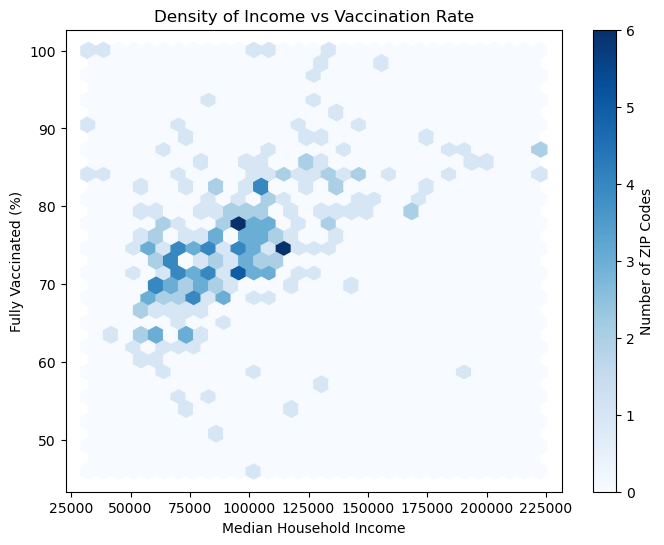

In [40]:
plt.figure(figsize=(8,6))

plt.hexbin(
    snapshot_with_income['median_income'],
    snapshot_with_income['fully_vaccinated_percent'],
    gridsize=30,
    cmap='Blues'
)

plt.colorbar(label='Number of ZIP Codes')

plt.title("Density of Income vs Vaccination Rate")
plt.xlabel("Median Household Income")
plt.ylabel("Fully Vaccinated (%)")

plt.ticklabel_format(style='plain', axis='x')

plt.show()

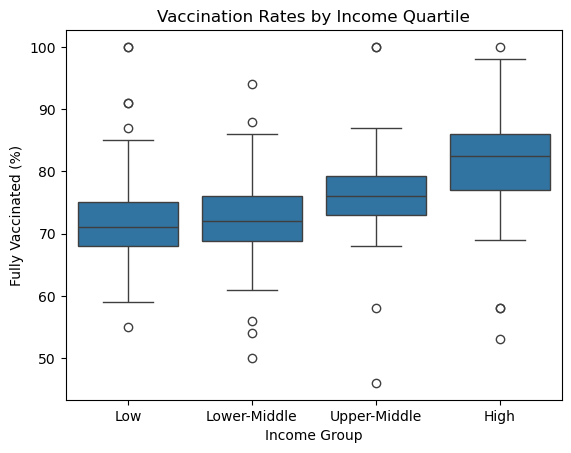

In [41]:
snapshot_with_income['income_group'] = pd.qcut(
    snapshot_with_income['median_income'],
    q=4,
    labels=['Low', 'Lower-Middle', 'Upper-Middle', 'High']
)

sns.boxplot(
    data=snapshot_with_income,
    x='income_group',
    y='fully_vaccinated_percent'
)

plt.title("Vaccination Rates by Income Quartile")
plt.xlabel("Income Group")
plt.ylabel("Fully Vaccinated (%)")

plt.show()

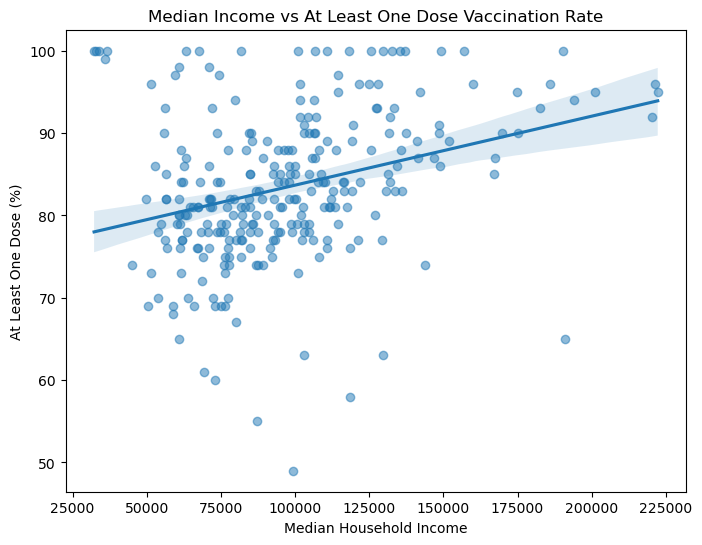

In [42]:
plt.figure(figsize=(8,6))

sns.regplot(
    data=snapshot_with_income,
    x='median_income',
    y='at_least_one_dose_percent',
    scatter_kws={'alpha':0.5}
)

plt.title("Median Income vs At Least One Dose Vaccination Rate")
plt.xlabel("Median Household Income")
plt.ylabel("At Least One Dose (%)")

plt.ticklabel_format(style='plain', axis='x')

plt.show()

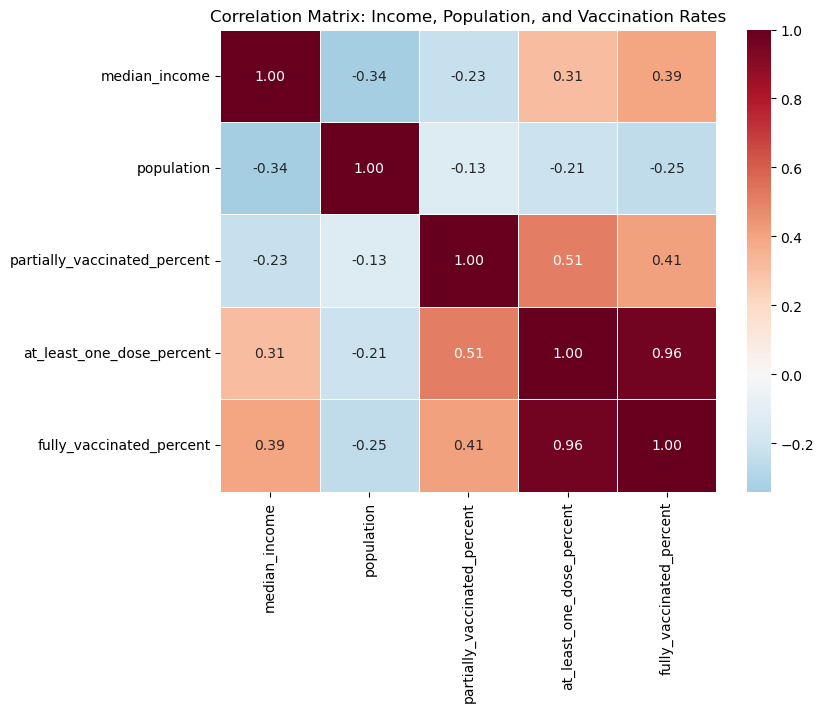

In [43]:
plt.figure(figsize=(8,6))

corr = snapshot_with_income[
    ['median_income',
     'population',
     'partially_vaccinated_percent',
     'at_least_one_dose_percent',
     'fully_vaccinated_percent']
].corr()

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    linewidths=0.5
)

plt.title("Correlation Matrix: Income, Population, and Vaccination Rates")

plt.show()

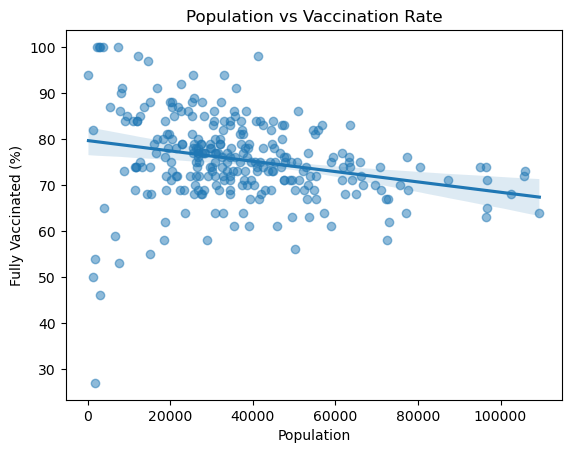

In [44]:
sns.regplot(
    data=snapshot_with_income,
    x='population',
    y='fully_vaccinated_percent',
    scatter_kws={'alpha':0.5}
)

plt.title("Population vs Vaccination Rate")
plt.xlabel("Population")
plt.ylabel("Fully Vaccinated (%)")
plt.show()

In [45]:
snapshot_with_income["zip"].unique()

array(['90001', '90002', '90003', '90004', '90005', '90006', '90007',
       '90008', '90010', '90011', '90012', '90013', '90014', '90015',
       '90016', '90017', '90018', '90019', '90020', '90021', '90022',
       '90023', '90024', '90025', '90026', '90027', '90028', '90029',
       '90031', '90032', '90033', '90034', '90035', '90036', '90037',
       '90038', '90039', '90040', '90041', '90042', '90043', '90044',
       '90045', '90046', '90047', '90048', '90049', '90056', '90057',
       '90058', '90059', '90061', '90062', '90063', '90064', '90065',
       '90066', '90067', '90068', '90069', '90071', '90077', '90094',
       '90201', '90210', '90211', '90212', '90220', '90221', '90222',
       '90230', '90232', '90240', '90241', '90242', '90245', '90247',
       '90248', '90249', '90250', '90254', '90255', '90260', '90262',
       '90263', '90265', '90266', '90270', '90272', '90274', '90275',
       '90277', '90278', '90280', '90290', '90291', '90292', '90293',
       '90301', '903

In [46]:
snapshot_with_income['zip'] = (
    snapshot_with_income['zip']
    .astype(str)
    .str.strip()
    .str.replace('.0','', regex=False)
)

In [47]:
zip_to_region = {
    # South LA
    '90001':'South LA','90002':'South LA','90003':'South LA','90004':'South LA',
    '90005':'South LA','90006':'South LA','90007':'South LA','90008':'South LA',
    '90010':'South LA','90011':'South LA','90012':'South LA','90013':'South LA',
    '90014':'South LA','90015':'South LA','90016':'South LA','90017':'South LA',
    '90018':'South LA','90019':'South LA','90020':'South LA','90021':'South LA',
    '90022':'South LA','90023':'South LA','90024':'South LA','90025':'South LA',
    '90026':'South LA','90027':'South LA','90028':'South LA','90029':'South LA',
    '90031':'South LA','90032':'South LA','90033':'South LA','90034':'South LA',
    '90035':'South LA','90036':'South LA','90037':'South LA','90038':'South LA',
    '90039':'South LA','90040':'South LA','90041':'South LA','90042':'South LA',
    '90043':'South LA','90044':'South LA','90045':'South LA','90046':'South LA',
    '90047':'South LA','90048':'South LA','90049':'South LA','90056':'South LA',
    '90057':'South LA','90058':'South LA','90059':'South LA','90061':'South LA',
    '90062':'South LA','90063':'South LA','90064':'South LA','90065':'South LA',
    '90066':'South LA','90067':'South LA','90068':'South LA','90069':'South LA',
    '90071':'South LA','90077':'South LA','90094':'South LA',

    # West LA / Santa Monica
    '90210':'West LA','90211':'West LA','90212':'West LA','90220':'West LA',
    '90221':'West LA','90222':'West LA','90230':'West LA','90232':'West LA',
    '90240':'West LA','90241':'West LA','90242':'West LA','90245':'West LA',
    '90247':'West LA','90248':'West LA','90249':'West LA','90250':'West LA',
    '90254':'West LA','90255':'West LA','90260':'West LA','90262':'West LA',
    '90263':'West LA','90265':'West LA','90266':'West LA','90270':'West LA',
    '90272':'West LA','90274':'West LA','90275':'West LA','90277':'West LA',
    '90278':'West LA','90280':'West LA','90290':'West LA','90291':'West LA',
    '90292':'West LA','90293':'West LA',

    # South Bay / Torrance / Redondo Beach
    '90301':'South Bay','90302':'South Bay','90303':'South Bay','90304':'South Bay',
    '90305':'South Bay','90401':'South Bay','90402':'South Bay','90403':'South Bay',
    '90404':'South Bay','90405':'South Bay','90501':'South Bay','90502':'South Bay',
    '90503':'South Bay','90504':'South Bay','90505':'South Bay','90701':'South Bay',
    '90703':'South Bay','90704':'South Bay','90706':'South Bay','90710':'South Bay',
    '90712':'South Bay','90713':'South Bay','90715':'South Bay','90716':'South Bay',
    '90717':'South Bay','90723':'South Bay','90746':'South Bay','90755':'South Bay',
    '90802':'South Bay','90803':'South Bay','90804':'South Bay','90805':'South Bay',
    '90806':'South Bay','90807':'South Bay','90808':'South Bay','90810':'South Bay',
    '90813':'South Bay','90814':'South Bay','90815':'South Bay',

    # San Gabriel Valley
    '91001':'San Gabriel Valley','91006':'San Gabriel Valley','91007':'San Gabriel Valley',
    '91008':'San Gabriel Valley','91010':'San Gabriel Valley','91011':'San Gabriel Valley',
    '91016':'San Gabriel Valley','91020':'San Gabriel Valley','91024':'San Gabriel Valley',
    '91030':'San Gabriel Valley','91040':'San Gabriel Valley','91042':'San Gabriel Valley',
    '91046':'San Gabriel Valley','91101':'San Gabriel Valley','91103':'San Gabriel Valley',
    '91104':'San Gabriel Valley','91105':'San Gabriel Valley','91106':'San Gabriel Valley',
    '91107':'San Gabriel Valley','91108':'San Gabriel Valley','91201':'San Gabriel Valley',
    '91202':'San Gabriel Valley','91203':'San Gabriel Valley','91204':'San Gabriel Valley',
    '91205':'San Gabriel Valley','91206':'San Gabriel Valley','91207':'San Gabriel Valley',
    '91208':'San Gabriel Valley','91214':'San Gabriel Valley','91301':'San Gabriel Valley',
    '91302':'San Gabriel Valley','91303':'San Gabriel Valley','91304':'San Gabriel Valley',
    '91306':'San Gabriel Valley','91307':'San Gabriel Valley','91311':'San Gabriel Valley',
    '91316':'San Gabriel Valley','91321':'San Gabriel Valley','91324':'San Gabriel Valley',
    '91325':'San Gabriel Valley','91326':'San Gabriel Valley','91331':'San Gabriel Valley',
    '91335':'San Gabriel Valley','91340':'San Gabriel Valley','91342':'San Gabriel Valley',
    '91343':'San Gabriel Valley','91344':'San Gabriel Valley','91345':'San Gabriel Valley',
    '91350':'San Gabriel Valley','91351':'San Gabriel Valley','91352':'San Gabriel Valley',
    '91354':'San Gabriel Valley','91355':'San Gabriel Valley','91356':'San Gabriel Valley',
    '91364':'San Gabriel Valley','91367':'San Gabriel Valley','91381':'San Gabriel Valley',
    '91384':'San Gabriel Valley','91387':'San Gabriel Valley','91390':'San Gabriel Valley',
    '91401':'San Gabriel Valley','91402':'San Gabriel Valley','91403':'San Gabriel Valley',
    '91405':'San Gabriel Valley','91406':'San Gabriel Valley','91411':'San Gabriel Valley',
    '91423':'San Gabriel Valley','91436':'San Gabriel Valley',

    # San Fernando Valley
    '91601':'San Fernando Valley','91602':'San Fernando Valley','91604':'San Fernando Valley',
    '91605':'San Fernando Valley','91606':'San Fernando Valley','91607':'San Fernando Valley',

    # Inland Empire
    '91702':'Inland Empire','91706':'Inland Empire','91711':'Inland Empire','91722':'Inland Empire',
    '91723':'Inland Empire','91724':'Inland Empire','91731':'Inland Empire','91732':'Inland Empire',
    '91733':'Inland Empire','91740':'Inland Empire','91741':'Inland Empire','91744':'Inland Empire',
    '91745':'Inland Empire','91746':'Inland Empire','91748':'Inland Empire','91750':'Inland Empire',
    '91754':'Inland Empire','91755':'Inland Empire','91765':'Inland Empire','91766':'Inland Empire',
    '91767':'Inland Empire','91768':'Inland Empire','91770':'Inland Empire','91773':'Inland Empire',
    '91775':'Inland Empire','91776':'Inland Empire','91780':'Inland Empire','91789':'Inland Empire',
    '91790':'Inland Empire','91791':'Inland Empire','91792':'Inland Empire',

    # Antelope Valley
    '93510':'Antelope Valley','93532':'Antelope Valley','93534':'Antelope Valley',
    '93535':'Antelope Valley','93536':'Antelope Valley','93543':'Antelope Valley',
    '93544':'Antelope Valley','93550':'Antelope Valley','93551':'Antelope Valley',
    '93552':'Antelope Valley','93553':'Antelope Valley','93591':'Antelope Valley',

    # Long Beach / Gateway Cities
    '90201':'Gateway Cities',  # Bell Gardens area
    # Whittier / La Habra / Northern LA County
    '90601':'Gateway Cities','90602':'Gateway Cities','90603':'Gateway Cities',
    '90604':'Gateway Cities','90605':'Gateway Cities','90606':'Gateway Cities',
    '90638':'Gateway Cities','90640':'Gateway Cities','90650':'Gateway Cities',
    '90660':'Gateway Cities','90670':'Gateway Cities',
    # South Bay / Torrance extension
    '90731':'South Bay','90732':'South Bay','90744':'South Bay','90745':'South Bay',
    # Pasadena / Altadena area
    '91501':'San Gabriel Valley','91502':'San Gabriel Valley','91504':'San Gabriel Valley',
    '91505':'San Gabriel Valley','91506':'San Gabriel Valley',
    # El Monte / Rosemead area
    '91801':'San Gabriel Valley','91803':'San Gabriel Valley'
}

In [48]:
snapshot_with_income['region'] = snapshot_with_income['zip'].map(zip_to_region)

In [49]:
snapshot_with_income['zip'] = snapshot_with_income['zip'].astype(str)

In [50]:
snapshot_with_income[snapshot_with_income['region'].isna()]['zip'].unique()

array([], dtype=object)

In [51]:
snapshot_with_income['region'] = snapshot_with_income['zip'].map(zip_to_region)

# Check for any still-missing ZIPs
missing_zips = snapshot_with_income[snapshot_with_income['region'].isna()]['zip'].unique()
print("Missing ZIPs:", missing_zips)

Missing ZIPs: []


In [52]:
snapshot_with_income

,date,id,county,fips,population,partially_vaccinated,at_least_one_dose,fully_vaccinated,partially_vaccinated_percent,at_least_one_dose_percent,fully_vaccinated_percent,zip,vax_rate,median_income_2023,median_income_2021,year,median_income,income_group,region
0,2023-05-30,90001,Los Angeles,37,58975.0,13713,58066,44353,0.23,98.0,75.0,90001,0.75,60751.0,52806.0,2023,60751.0,Low,South LA
1,2023-05-30,90002,Los Angeles,37,53111.0,5338,40763,35425,0.10,77.0,67.0,90002,0.67,56158.0,46159.0,2023,56158.0,Low,South LA
2,2023-05-30,90003,Los Angeles,37,72741.0,8531,57564,49033,0.12,79.0,67.0,90003,0.67,54781.0,47733.0,2023,54781.0,Low,South LA
3,2023-05-30,90004,Los Angeles,37,61586.0,5969,53241,47272,0.10,86.0,77.0,90004,0.77,62655.0,54947.0,2023,62655.0,Low,South LA
4,2023-05-30,90005,Los Angeles,37,39479.0,4436,33905,29469,0.11,86.0,75.0,90005,0.75,52755.0,44913.0,2023,52755.0,Low,South LA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
271,2023-05-30,93550,Los Angeles,37,77006.0,5170,54215,49045,0.07,70.0,64.0,93550,0.64,63811.0,54693.0,2023,63811.0,Low,Antelope Valley
272,2023-05-30,93551,Los Angeles,37,51085.0,2921,39150,36229,0.06,77.0,71.0,93551,0.71,110850.0,98181.0,2023,110850.0,Upper-Middle,Antelope Valley
273,2023-05-30,93552,Los Angeles,37,40266.0,2503,30546,28043,0.06,76.0,70.0,93552,0.70,84894.0,73074.0,2023,84894.0,Lower-Middle,Antelope Valley
274,2023-05-30,93553,Los Angeles,37,1781.0,100,1061,961,0.06,60.0,54.0,93553,0.54,73029.0,59805.0,2023,73029.0,Lower-Middle,Antelope Valley


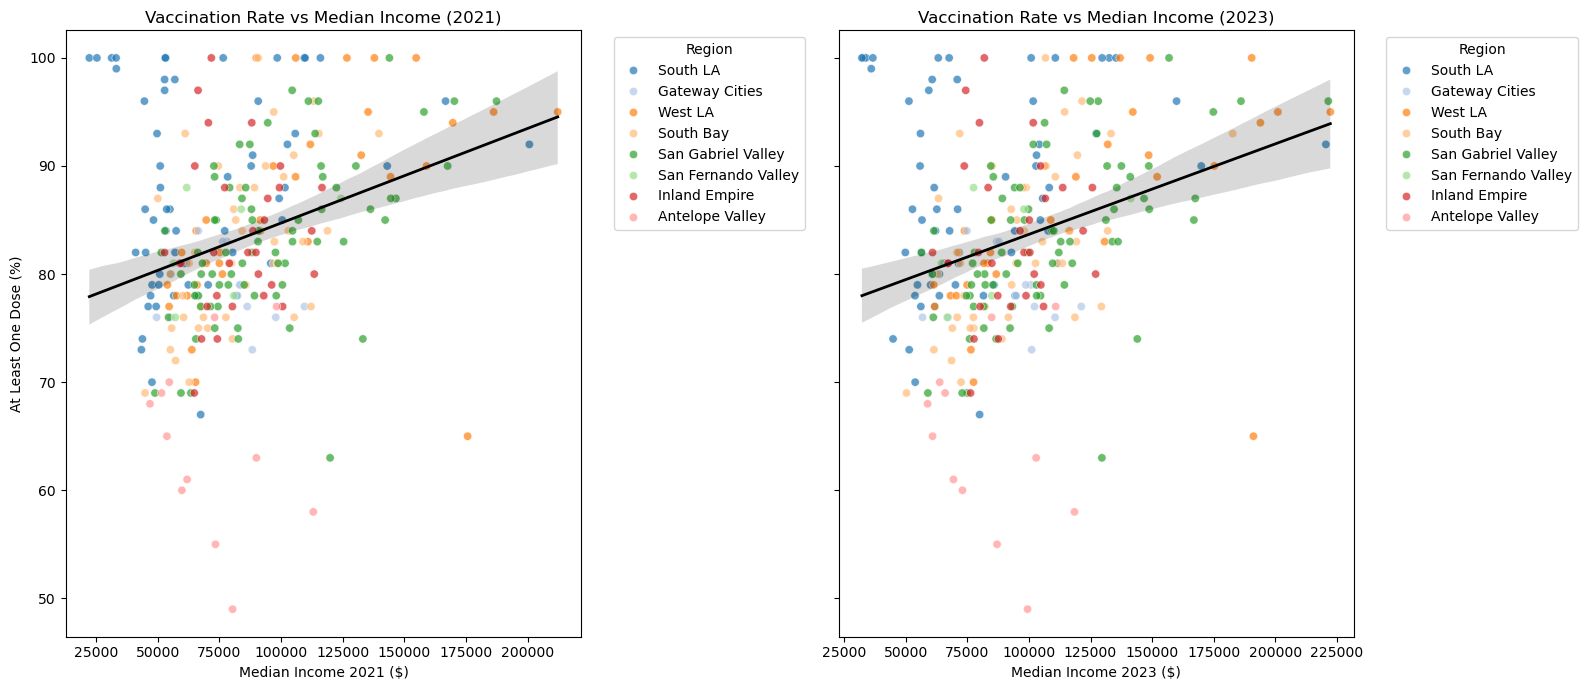

In [54]:
# --- 1. Convert median incomes to numeric ---
snapshot_with_income['median_income_2021'] = pd.to_numeric(
    snapshot_with_income['median_income_2021'].replace('[\$,]', '', regex=True),
    errors='coerce'
)
snapshot_with_income['median_income_2023'] = pd.to_numeric(
    snapshot_with_income['median_income_2023'].replace('[\$,]', '', regex=True),
    errors='coerce'
)

# --- 2. Cap vaccination percentages at 100 ---
snapshot_with_income['at_least_one_dose_percent'] = snapshot_with_income['at_least_one_dose_percent'].clip(upper=100)
snapshot_with_income['fully_vaccinated_percent'] = snapshot_with_income['fully_vaccinated_percent'].clip(upper=100)

# --- 3. Split datasets by year ---
df_2021 = snapshot_with_income[['zip', 'at_least_one_dose_percent', 'region', 'median_income_2021']].dropna()
df_2023 = snapshot_with_income[['zip', 'at_least_one_dose_percent', 'region', 'median_income_2023']].dropna()

# --- 4. Create side-by-side scatter plots with regression lines ---
fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True)

# 2021 plot
sns.scatterplot(
    data=df_2021,
    x='median_income_2021',
    y='at_least_one_dose_percent',
    hue='region',
    palette='tab20',
    ax=axes[0],
    alpha=0.7
)
sns.regplot(
    data=df_2021,
    x='median_income_2021',
    y='at_least_one_dose_percent',
    scatter=False,
    ax=axes[0],
    color='black',
    line_kws={'linewidth':2}
)
axes[0].set_title('Vaccination Rate vs Median Income (2021)')
axes[0].set_xlabel('Median Income 2021 ($)')
axes[0].set_ylabel('At Least One Dose (%)')
axes[0].legend(title='Region', bbox_to_anchor=(1.05, 1), loc='upper left')

# 2023 plot
sns.scatterplot(
    data=df_2023,
    x='median_income_2023',
    y='at_least_one_dose_percent',
    hue='region',
    palette='tab20',
    ax=axes[1],
    alpha=0.7
)
sns.regplot(
    data=df_2023,
    x='median_income_2023',
    y='at_least_one_dose_percent',
    scatter=False,
    ax=axes[1],
    color='black',
    line_kws={'linewidth':2}
)
axes[1].set_title('Vaccination Rate vs Median Income (2023)')
axes[1].set_xlabel('Median Income 2023 ($)')
axes[1].set_ylabel('')  # hide ylabel to avoid duplication
axes[1].legend(title='Region', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

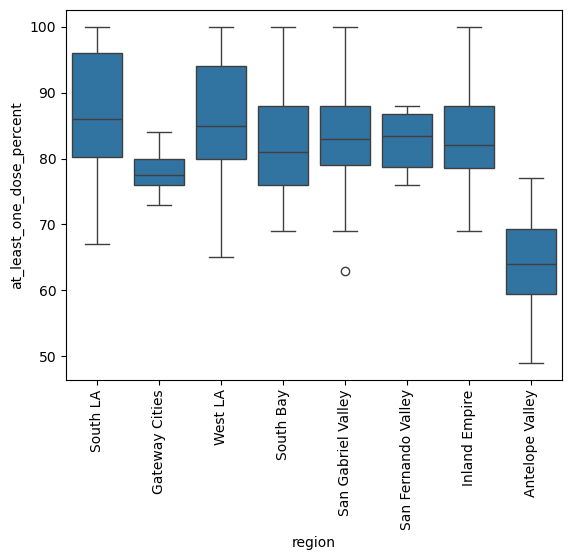

In [56]:
sns.boxplot(data=df_2023, x='region', y='at_least_one_dose_percent')
plt.xticks(rotation=90)
plt.show()

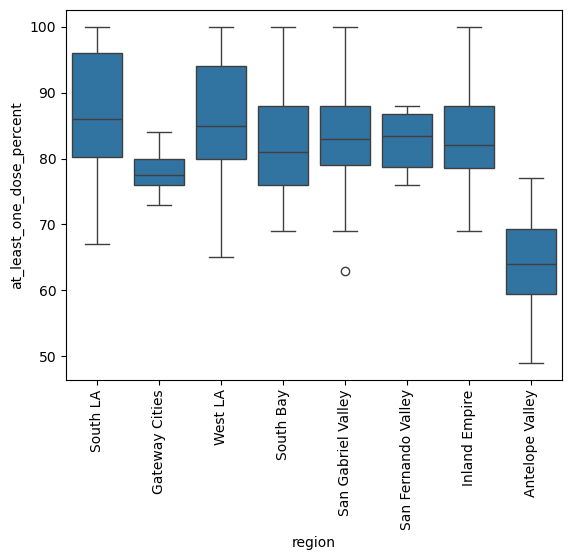

In [57]:
sns.boxplot(data=df_2021, x='region', y='at_least_one_dose_percent')
plt.xticks(rotation=90)
plt.show()

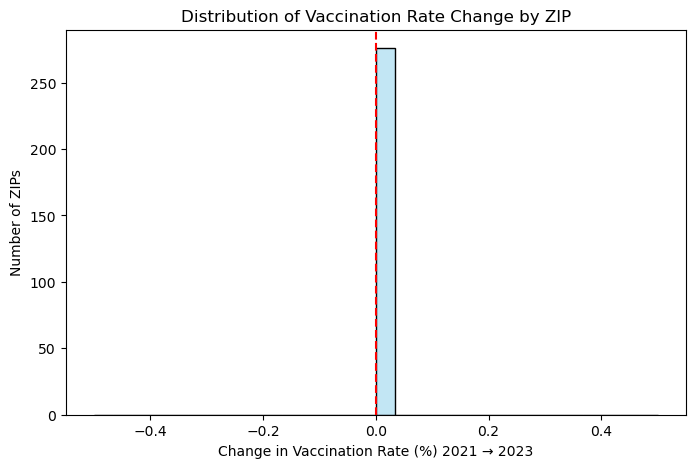

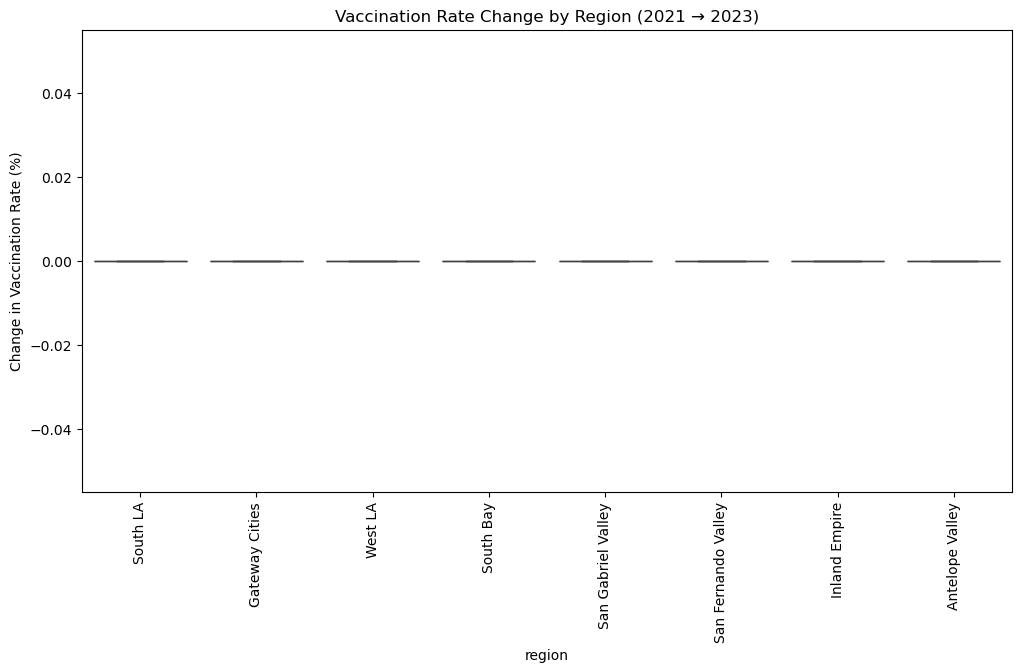

In [59]:
# Compute change
snapshot_with_income['vax_change'] = (
    snapshot_with_income['at_least_one_dose_percent'] - snapshot_with_income['at_least_one_dose_percent']  # update with proper column names if different
)

# Histogram of change
plt.figure(figsize=(8,5))
sns.histplot(snapshot_with_income['vax_change'], bins=30, kde=True, color='skyblue')
plt.axvline(0, color='red', linestyle='--')
plt.xlabel('Change in Vaccination Rate (%) 2021 → 2023')
plt.ylabel('Number of ZIPs')
plt.title('Distribution of Vaccination Rate Change by ZIP')
plt.show()

# Boxplot by region
plt.figure(figsize=(12,6))
sns.boxplot(data=snapshot_with_income, x='region', y='vax_change')
plt.xticks(rotation=90)
plt.ylabel('Change in Vaccination Rate (%)')
plt.title('Vaccination Rate Change by Region (2021 → 2023)')
plt.show()

/tmp/ipykernel_1043/1458888714.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  heatmap_data = snapshot_with_income.pivot_table(


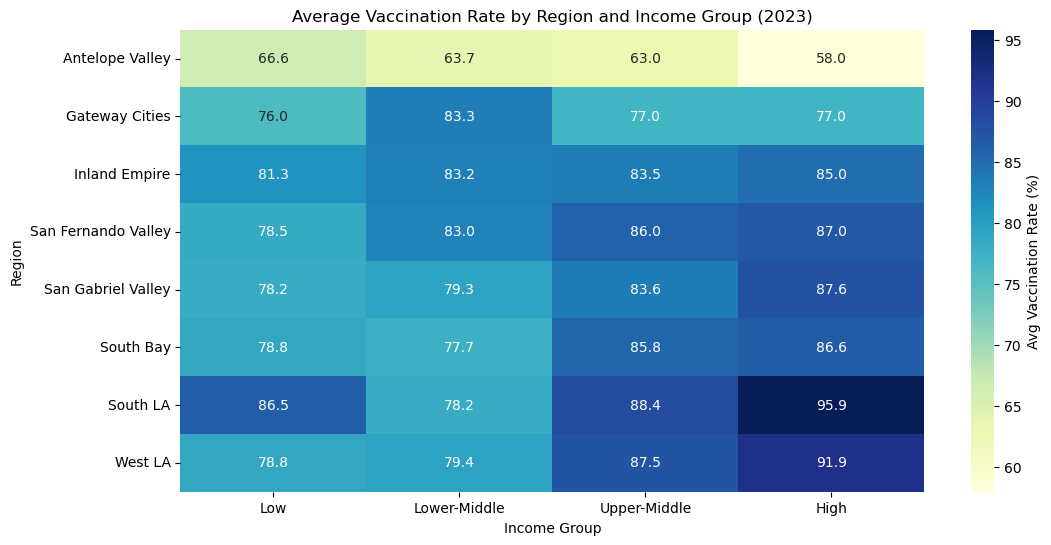

In [60]:
# Pivot table: average vaccination by region and income group
heatmap_data = snapshot_with_income.pivot_table(
    index='region',
    columns='income_group',
    values='at_least_one_dose_percent',  # or fully_vaccinated_percent
    aggfunc='mean'
)

plt.figure(figsize=(12,6))
sns.heatmap(heatmap_data, annot=True, fmt=".1f", cmap='YlGnBu', cbar_kws={'label': 'Avg Vaccination Rate (%)'})
plt.title('Average Vaccination Rate by Region and Income Group (2023)')
plt.ylabel('Region')
plt.xlabel('Income Group')
plt.show()

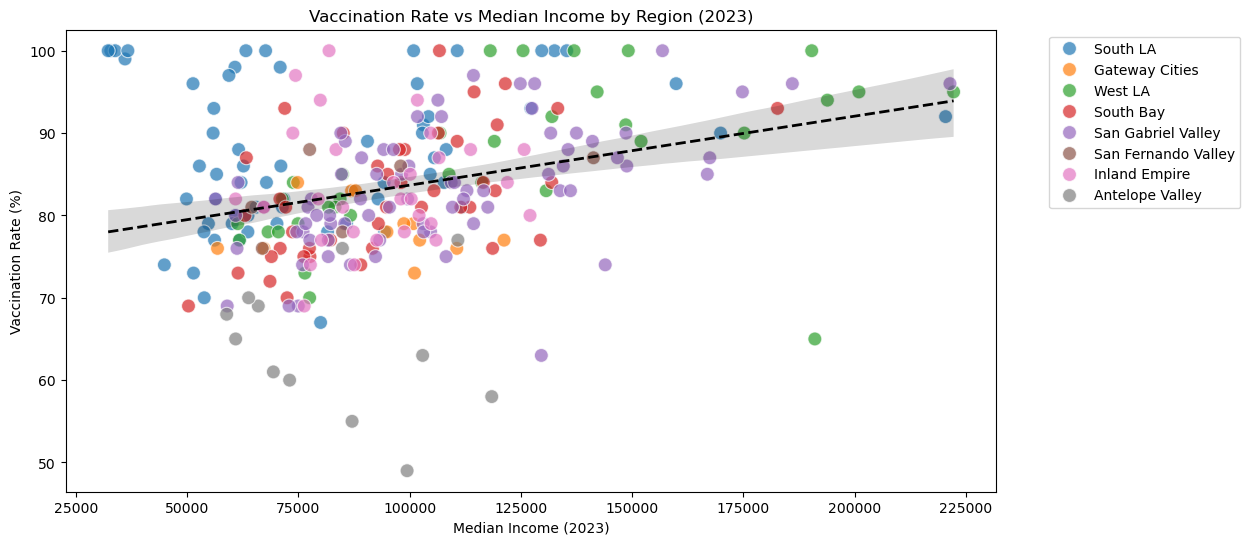

In [61]:
plt.figure(figsize=(12,6))
sns.scatterplot(
    data=snapshot_with_income,
    x='median_income_2023',        # or 'median_income_2021' if available
    y='at_least_one_dose_percent',
    hue='region',
    palette='tab10',
    s=100,
    alpha=0.7
)
sns.regplot(
    data=snapshot_with_income,
    x='median_income_2023',
    y='at_least_one_dose_percent',
    scatter=False,
    color='black',
    line_kws={'linewidth':2, 'linestyle':'--'}
)
plt.xlabel('Median Income (2023)')
plt.ylabel('Vaccination Rate (%)')
plt.title('Vaccination Rate vs Median Income by Region (2023)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

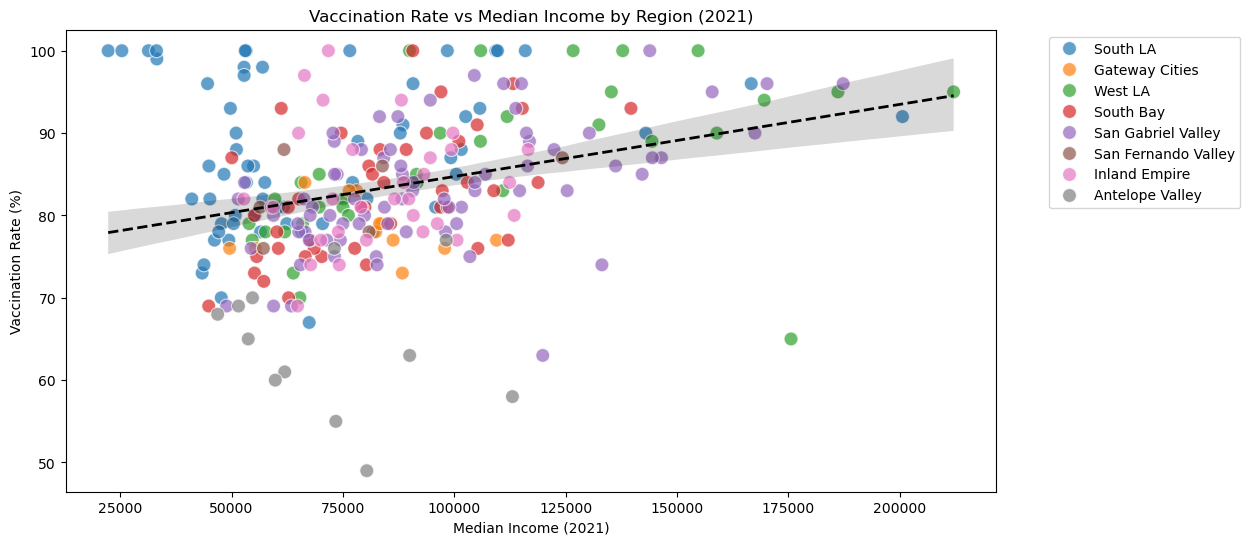

In [62]:
plt.figure(figsize=(12,6))
sns.scatterplot(
    data=snapshot_with_income,
    x='median_income_2021',        # or 'median_income_2021' if available
    y='at_least_one_dose_percent',
    hue='region',
    palette='tab10',
    s=100,
    alpha=0.7
)
sns.regplot(
    data=snapshot_with_income,
    x='median_income_2021',
    y='at_least_one_dose_percent',
    scatter=False,
    color='black',
    line_kws={'linewidth':2, 'linestyle':'--'}
)
plt.xlabel('Median Income (2021)')
plt.ylabel('Vaccination Rate (%)')
plt.title('Vaccination Rate vs Median Income by Region (2021)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [63]:
#hi